<a href="https://colab.research.google.com/github/EricFlores1808/E-I/blob/main/SocialMediaImpact_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Impacto de las Redes Sociales en la Salud Mental de Adolescentes
---
**Asignatura:** Minería de Datos — BIY7121-004-D

**Estudiantes:**
- Luis Saldías
- Eric Flores

**Docente:** Carlos Humberto Muñoz Salgado

**Dataset:** Teen Mental Health Dataset

---
> Este proyecto analiza cómo el uso diario de redes sociales afecta indicadores de salud mental en adolescentes, incluyendo estrés, ansiedad, adicción y depresión. Se aplican técnicas de análisis exploratorio, encoding de variables y modelos predictivos de clasificación y regresión.

---
##  SECCIÓN 1 — Configuración del Entorno
Instalación e importación de todas las librerías necesarias para el análisis.

In [1]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, mean_absolute_error, r2_score)
from sklearn.feature_selection import mutual_info_classif

In [3]:
# Estilo visual global — aplica a todos los gráficos del notebook
sb.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})
print("✅ Entorno configurado correctamente.")

✅ Entorno configurado correctamente.


---
##  SECCIÓN 2 — Carga y Comprensión de los Datos
El objetivo de esta sección es transformar el dataset crudo en una estructura de datos (DataFrame) que nos permita manipular y analizar las variables de salud mental de los adolescentes. Este paso es el punto de partida para la etapa de Comprensión de los Datos.

In [4]:
df = pd.read_csv("/content/Teen_Mental_Health_Dataset.csv")
print(f"Dataset cargado: {df.shape[0]} registros, {df.shape[1]} variables")
df.head()

Dataset cargado: 1200 registros, 13 variables


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


Para otorgar contexto al análisis, realizamos un mapeo de los tipos de datos. No todas las variables se tratan igual: la edad es numérica, pero el nivel de estrés es una escala ordinal. Identificar esto evita errores metodológicos al aplicar funciones estadísticas.

In [5]:
print("─── Información general del Dataset ───")
df.info()

─── Información general del Dataset ───
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5)

Un análisis es tan bueno como la calidad de sus datos. Realizamos una auditoría técnica buscando valores nulos o duplicados. La ausencia de estos problemas garantiza que las conclusiones no estén sesgadas por errores de registro o datos faltantes.

In [6]:
print("─── Auditoría de calidad de datos ───")
print(f"Valores nulos por columna:")
print(df.isna().sum())
print(f"\nRegistros duplicados: {df.duplicated().sum()}")
print("\n✅ Dataset limpio: sin nulos ni duplicados.")

─── Auditoría de calidad de datos ───
Valores nulos por columna:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Registros duplicados: 0

✅ Dataset limpio: sin nulos ni duplicados.


A continuación revisamos la distribución de las variables categóricas principales: plataforma de uso, nivel de interacción social y género. Esto nos permite entender la composición de la muestra antes de visualizarla.

In [7]:
print("─── Distribución de variables categóricas ───")
print("\nPlataforma de uso:")
print(df['platform_usage'].value_counts())
print("\nNivel de interacción social:")
print(df['social_interaction_level'].value_counts())
print("\nGénero:")
print(df['gender'].value_counts())

─── Distribución de variables categóricas ───

Plataforma de uso:
platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

Nivel de interacción social:
social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

Género:
gender
male      615
female    585
Name: count, dtype: int64


El método `.describe()` nos entrega un resumen estadístico de todas las variables numéricas: media, desviación estándar, mínimo, máximo y percentiles. Esto nos da una primera visión del comportamiento de los indicadores de salud mental.

In [8]:
df.describe().round(2)

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,15.93,4.54,6.45,1.74,2.99,1.01,5.45,5.64,5.56,0.03
std,2.02,2.03,1.44,0.72,0.58,0.58,2.90,2.86,2.83,0.16
min,13.00,1.00,4.00,0.50,2.00,0.00,1.00,1.00,1.00,0.00
25%,14.00,2.80,5.20,1.10,2.50,0.50,3.00,3.00,3.00,0.00
50%,16.00,4.50,6.50,1.80,2.99,1.00,5.00,6.00,6.00,0.00
75%,18.00,6.30,7.60,2.40,3.48,1.50,8.00,8.00,8.00,0.00
max,19.00,8.00,9.00,3.00,4.00,2.00,10.00,10.00,10.00,1.00


**Interpretación:** El promedio de horas en redes sociales ronda las 5 horas diarias, lo que indica una alta exposición digital. El nivel de estrés promedio se sitúa en 5 sobre 10, sugiriendo niveles de tensión emocional considerables en la muestra. Los indicadores de ansiedad y adicción muestran valores similares, lo que anticipa una posible correlación entre ellos.

---
##  SECCIÓN 3 — Análisis Exploratorio y Visualización
En esta sección construimos visualizaciones para entender la composición de la muestra y las relaciones entre las variables principales.

### 3.1 Composición de la muestra
Analizamos la distribución por género, plataforma de uso y rango de edad. Esto nos permite identificar si el impacto en la salud mental podría estar condicionado por alguna de estas variables demográficas.

/tmp/ipykernel_938/2429784511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=df, x='gender', palette='pastel', ax=ax[0])
/tmp/ipykernel_938/2429784511.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=df, x='platform_usage', palette='viridis', ax=ax[1])


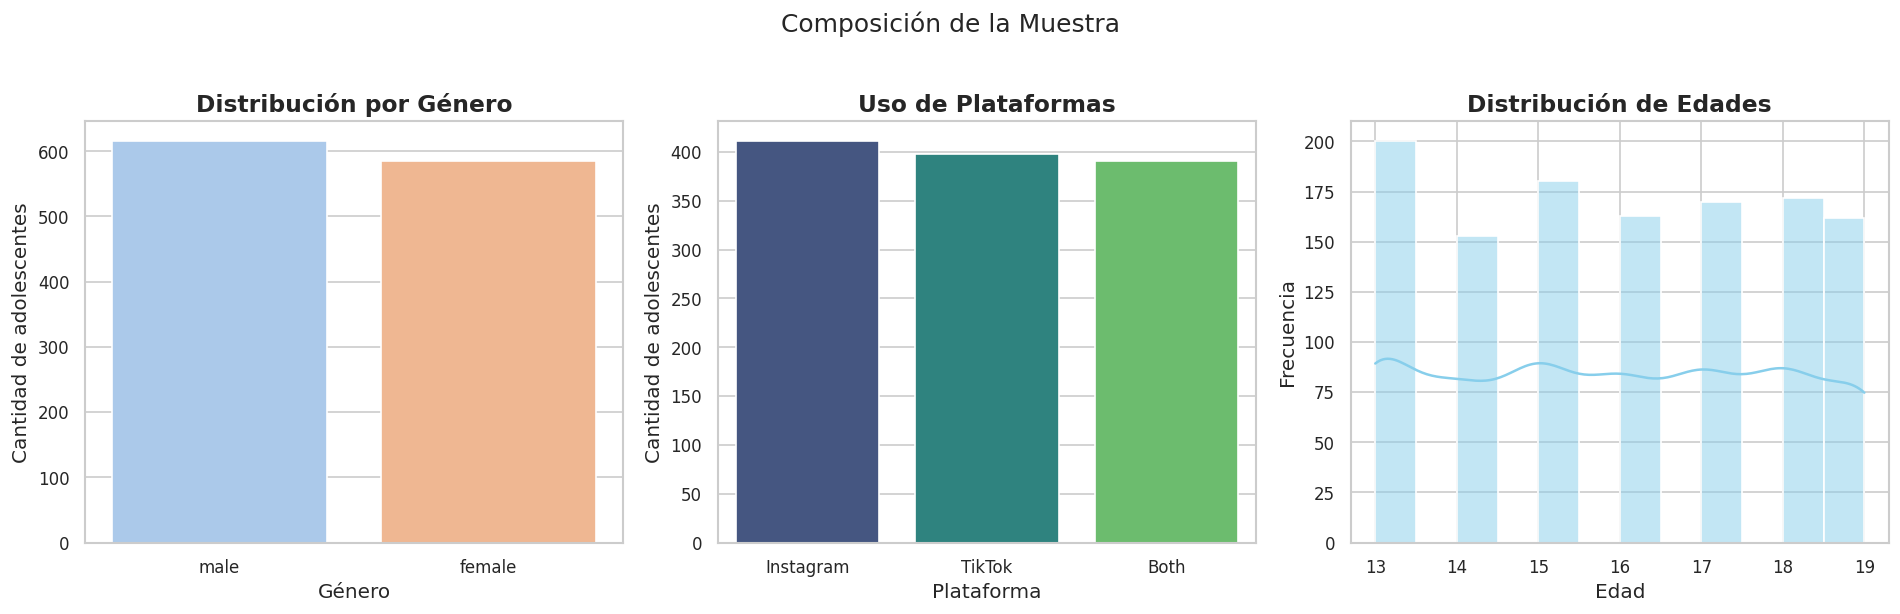

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 5))

sb.countplot(data=df, x='gender', palette='pastel', ax=ax[0])
ax[0].set_title('Distribución por Género')
ax[0].set_xlabel('Género')
ax[0].set_ylabel('Cantidad de adolescentes')

sb.countplot(data=df, x='platform_usage', palette='viridis', ax=ax[1])
ax[1].set_title('Uso de Plataformas')
ax[1].set_xlabel('Plataforma')
ax[1].set_ylabel('Cantidad de adolescentes')

sb.histplot(df['age'], kde=True, color='skyblue', ax=ax[2])
ax[2].set_title('Distribución de Edades')
ax[2].set_xlabel('Edad')
ax[2].set_ylabel('Frecuencia')

plt.suptitle('Composición de la Muestra', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Interpretación:** La muestra está balanceada equitativamente entre géneros y no hay una plataforma que domine sobre otra, lo que hace que el análisis de impacto sea representativo para todos los grupos. La edad se concentra en la adolescencia media, etapa crítica para el desarrollo de hábitos digitales y trastornos de salud mental.

### 3.2 Distribución de indicadores de salud mental
Visualizamos la distribución de los tres indicadores principales: estrés, ansiedad y adicción, mediante un diagrama de cajas que nos permite identificar la dispersión y los valores atípicos de cada uno.

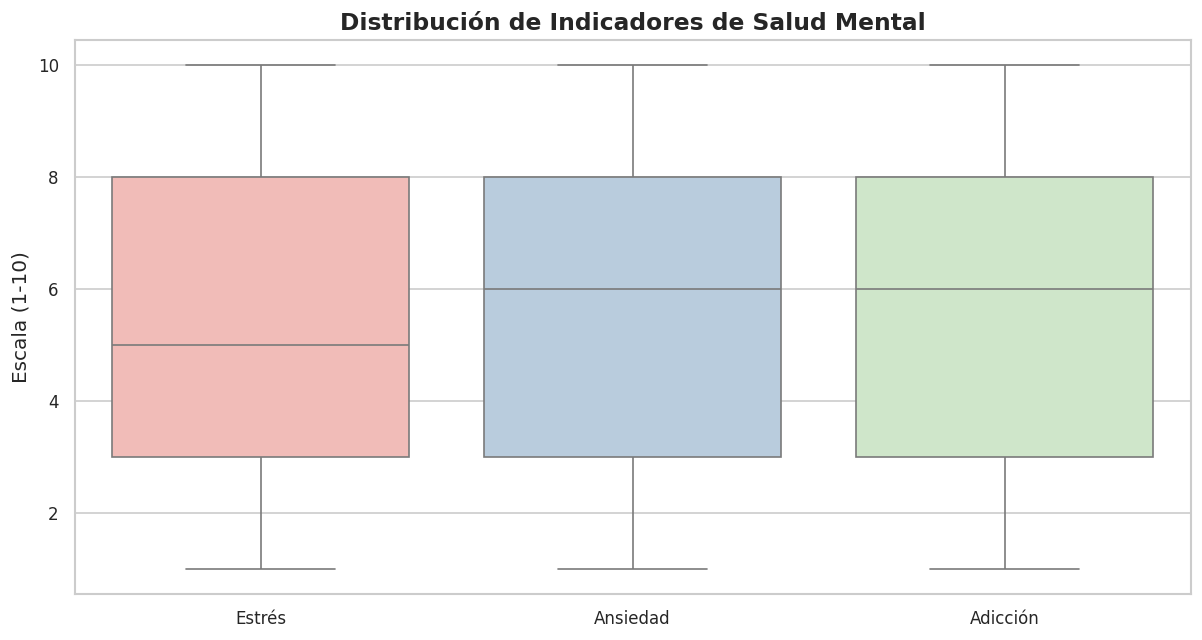

In [10]:
plt.figure(figsize=(12, 6))
health_vars = ['stress_level', 'anxiety_level', 'addiction_level']
sb.boxplot(data=df[health_vars], palette="Pastel1")
plt.title('Distribución de Indicadores de Salud Mental')
plt.ylabel('Escala (1-10)')
plt.xticks([0, 1, 2], ['Estrés', 'Ansiedad', 'Adicción'])
plt.show()

**Interpretación:** Los tres indicadores muestran una distribución homogénea, con medianas entre 5 y 6 y rangos similares. Esto sugiere que el estrés, la ansiedad y la adicción tienden a concentrarse en valores moderados-altos, sin presencia de outliers notables. La similitud entre los tres indicadores anticipa una posible correlación entre ellos, lo que exploraremos en la matriz de correlación.

### 3.3 Impacto del uso de redes sociales en el rendimiento académico
Analizamos si existe una relación lineal entre las horas diarias en redes sociales y el rendimiento académico (GPA) mediante un gráfico de dispersión con línea de regresión.

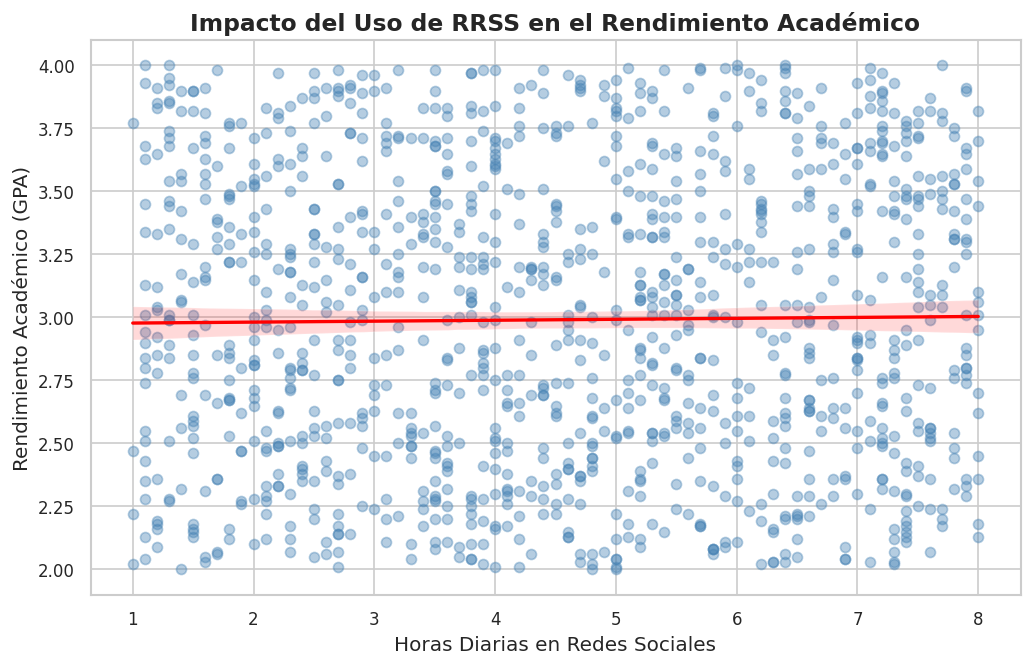

In [11]:
plt.figure(figsize=(10, 6))
sb.regplot(data=df, x='daily_social_media_hours', y='academic_performance',
           scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
           line_kws={'color': 'red', 'linewidth': 2})
plt.title('Impacto del Uso de RRSS en el Rendimiento Académico')
plt.xlabel('Horas Diarias en Redes Sociales')
plt.ylabel('Rendimiento Académico (GPA)')
plt.show()

**Interpretación:** Los datos muestran que el tiempo diario en redes sociales no tiene un impacto lineal significativo sobre el rendimiento académico. Independientemente de las horas de uso, el GPA tiende a mantenerse en un rango similar. Esto sugiere que la relación entre ambas variables es más compleja y no puede capturarse con una correlación lineal simple, lo que justifica el uso de modelos no lineales como el Árbol de Decisión en las secciones siguientes.

### 3.4 Nivel de estrés según interacción social
Comparamos el nivel de estrés promedio entre adolescentes con distintos niveles de interacción social (baja, media, alta) para determinar si socializar más se asocia con menor estrés.

/tmp/ipykernel_938/3257446008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=df, x='social_interaction_level', y='stress_level',


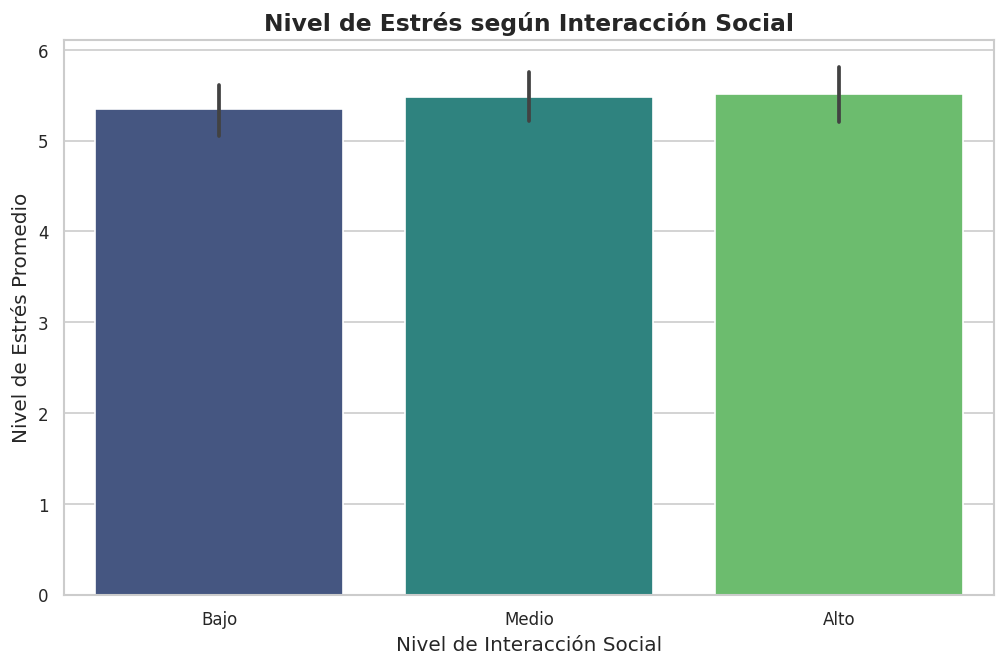

In [12]:
plt.figure(figsize=(10, 6))
sb.barplot(data=df, x='social_interaction_level', y='stress_level',
           order=['low', 'medium', 'high'], palette="viridis")
plt.title('Nivel de Estrés según Interacción Social')
plt.xlabel('Nivel de Interacción Social')
plt.ylabel('Nivel de Estrés Promedio')
plt.xticks([0, 1, 2], ['Bajo', 'Medio', 'Alto'])
plt.show()

**Interpretación:** Las diferencias en el nivel de estrés entre los tres grupos de interacción social son mínimas y prácticamente insignificantes. Contrario a lo esperado, una mayor interacción social no se asocia con menor estrés en esta muestra, lo que sugiere que la interacción social real no es un factor determinante del estrés por sí sola, o que su efecto está mediado por otras variables.

---
##  SECCIÓN 4 — Encoding de Variables Categóricas
Para que el dataset sea admisible en los modelos de machine learning, debemos transformar las variables cualitativas a formato numérico. Los algoritmos matemáticos no pueden procesar texto directamente.

Aplicamos tres técnicas de encoding según el tipo de cada variable:
- **Label Encoding (Ordinal):** para `social_interaction_level`, que tiene un orden natural (bajo < medio < alto).
- **One-Hot Encoding:** para `platform_usage` y `gender`, que son variables nominales sin orden.
- **Binary Encoding:** para `gender`, técnica alternativa que reduce la dimensionalidad.

In [13]:
# Proceso de Encoding para variables categóricas
df_encoded = df.copy()

# 1. Label Encoding para social_interaction_level (variable ordinal)
map_social = {'low': 0, 'medium': 1, 'high': 2}
df_encoded['social_interaction_level'] = df_encoded['social_interaction_level'].map(map_social)

# 2. One-Hot Encoding para platform_usage y gender (variables nominales)
# Genera columnas binarias por cada categoría
df_encoded = pd.get_dummies(df_encoded, columns=['platform_usage', 'gender'], drop_first=True)

print("✅ Encoding completado.")
print(f"Columnas resultantes: {list(df_encoded.columns)}")

✅ Encoding completado.
Columnas resultantes: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label', 'platform_usage_Instagram', 'platform_usage_TikTok', 'gender_male']


**Resultado del Encoding:** el dataset ha pasado de tener columnas de texto a una matriz completamente numérica. Ahora contamos con columnas específicas como `platform_usage_TikTok`, `gender_Male`, etc. Esto nos permitirá calcular correlaciones y entrenar modelos en las siguientes secciones.

---
##  SECCIÓN 5 — Matriz de Correlación de Pearson
Analizamos las relaciones lineales entre todas las variables numéricas del dataset utilizando el coeficiente de correlación de Pearson.

Los valores van de -1 a 1:
- **Cercano a 1:** correlación positiva fuerte (cuando una sube, la otra también).
- **Cercano a -1:** correlación negativa fuerte (cuando una sube, la otra baja).
- **Cercano a 0:** sin relación lineal.

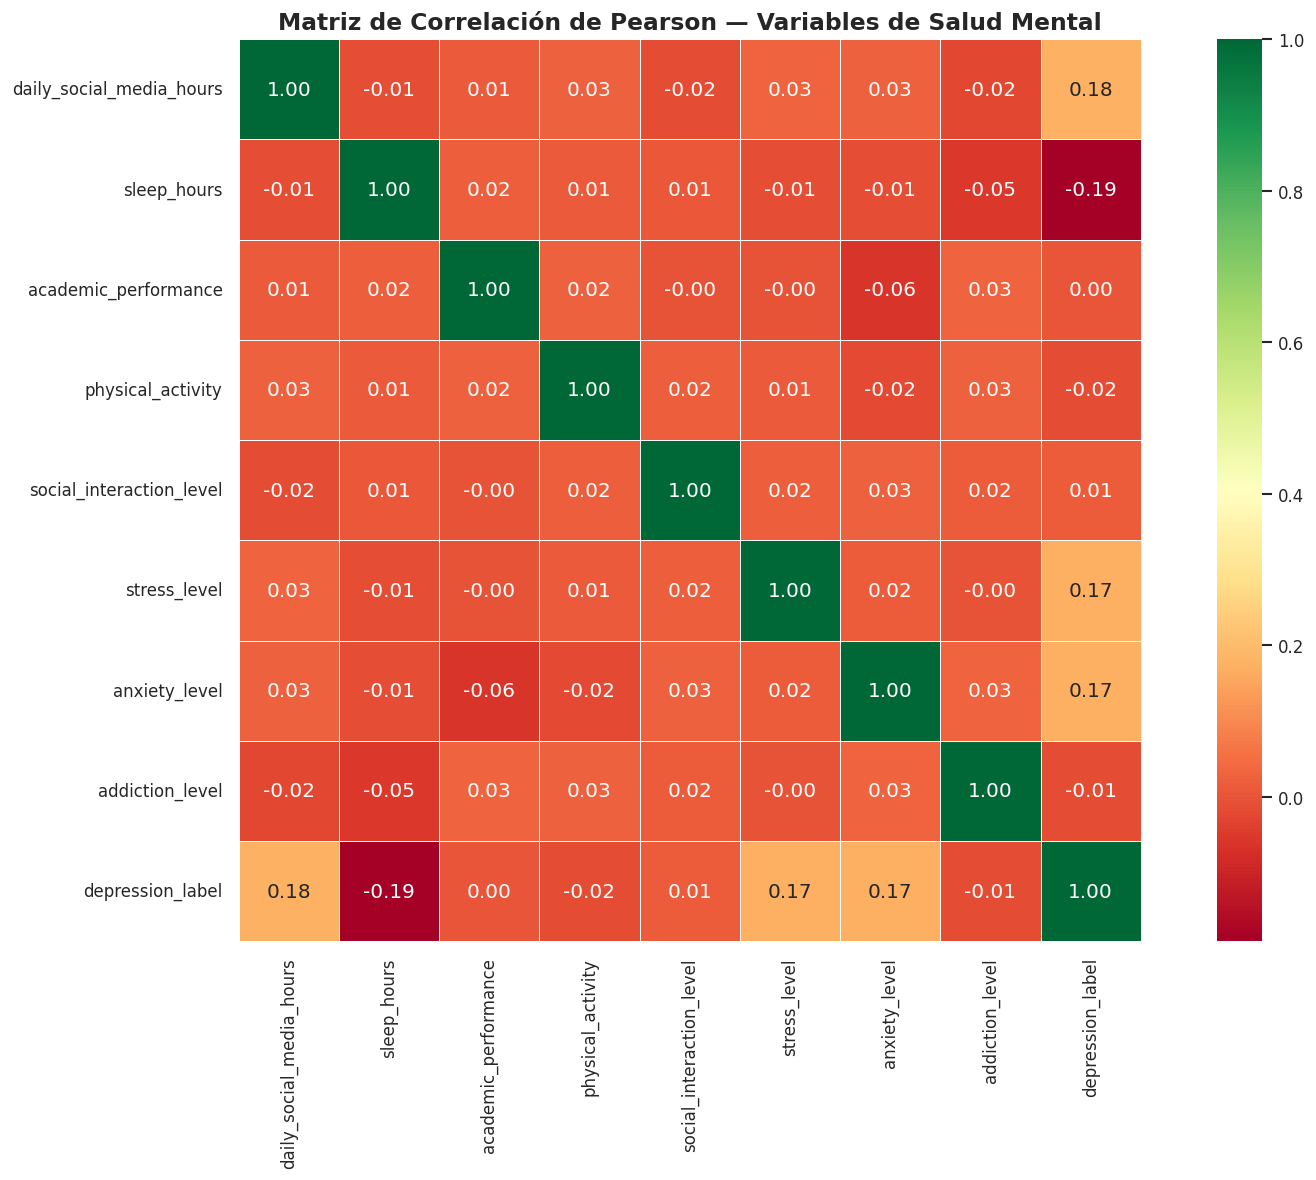

In [14]:
# Eliminamos columnas no numéricas para la matriz
cols_to_remove = [col for col in df_encoded.columns
                  if 'platform_usage' in col or 'gender' in col
                  or col in ['age', 'screen_time_before_sleep']]

df_filtered = df_encoded.drop(columns=cols_to_remove)

plt.figure(figsize=(14, 10))
sb.heatmap(df_filtered.corr(), annot=True, cmap='RdYlGn', fmt=".2f",
           linewidths=0.5, square=True)
plt.title('Matriz de Correlación de Pearson — Variables de Salud Mental')
plt.tight_layout()
plt.show()

**Interpretación:** La mayoría de las correlaciones son bajas (cercanas a 0), lo que indica que ninguna variable por sí sola explica fuertemente el comportamiento de otra de forma lineal. Esto **no significa que las variables no tengan relación con la depresión**, sino que dicha relación no es lineal ni se explica por una sola variable a la vez.



---
##  SECCIÓN 6 — Árbol de Decisión Clasificador
### Predicción de depresión en adolescentes

Aplicamos un **Árbol de Decisión Clasificador** para predecir si un adolescente presenta indicadores de depresión (`depression_label`: 0 = sin depresión, 1 = con depresión).

**Justificación del modelo:** la variable objetivo es binaria (0/1), lo que hace al árbol de clasificación el modelo más adecuado. Este mismo enfoque fue visto en clases con la predicción de lluvia/no lluvia.

### 6.1 Selección de variables e importancia previa al entrenamiento
Antes de entrenar el modelo, medimos qué variables aportan más información para distinguir entre los dos grupos, usando **información mutua**.

In [15]:
# Variables predictoras numéricas
X_clf = df[['daily_social_media_hours', 'sleep_hours',
            'screen_time_before_sleep', 'academic_performance',
            'physical_activity', 'stress_level', 'anxiety_level',
            'addiction_level']]

# Variable objetivo binaria
y_clf = df['depression_label']

print("Variables predictoras:", list(X_clf.columns))
print(f"\nDistribución del target:")
print(y_clf.value_counts())
print(f"\nPorcentaje con depresión: {y_clf.mean():.1%}")

Variables predictoras: ['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']

Distribución del target:
depression_label
0    1169
1      31
Name: count, dtype: int64

Porcentaje con depresión: 2.6%


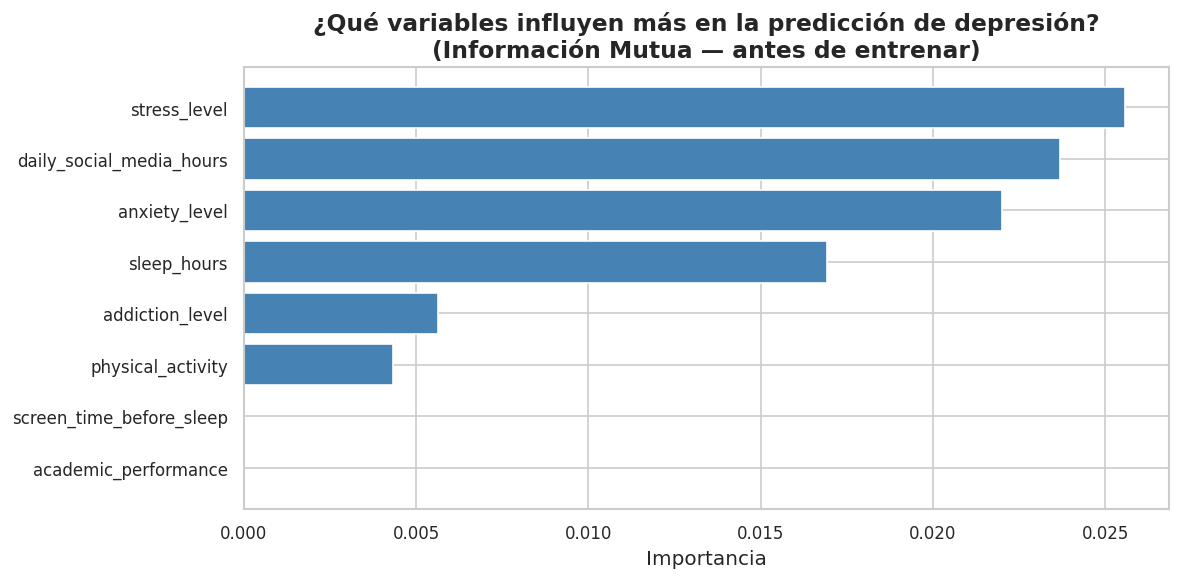

In [16]:
# Importancia de variables con información mutua
importancia = mutual_info_classif(X_clf, y_clf, discrete_features=False)

df_importancia = pd.DataFrame({
    'Variable': X_clf.columns,
    'Importancia': importancia
}).sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(df_importancia['Variable'], df_importancia['Importancia'], color='steelblue')
plt.title('¿Qué variables influyen más en la predicción de depresión?\n(Información Mutua — antes de entrenar)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

**Interpretación:** La barra más larga indica la variable que más información aporta para distinguir si un adolescente presenta o no depresión. Estas son las variables que el modelo priorizará al aprender las reglas de clasificación.

### 6.2 Entrenamiento del modelo

In [17]:
# División en entrenamiento (80%) y prueba (20%)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

print(f"Registros de entrenamiento: {X_train_clf.shape[0]}")
print(f"Registros de prueba:        {X_test_clf.shape[0]}")

# Entrenamiento
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train_clf, y_train_clf)

# Predicciones sobre datos NO vistos
preds_clf = clf.predict(X_test_clf)

print(f"\n✅ Modelo entrenado.")
print(f"Precisión del Clasificador: {accuracy_score(y_test_clf, preds_clf):.2%}")

Registros de entrenamiento: 960
Registros de prueba:        240

✅ Modelo entrenado.
Precisión del Clasificador: 98.33%


### 6.3 Visualización del árbol de decisión
Cada nodo del árbol realiza una pregunta sobre una variable. En función de la respuesta, el árbol desciende por una rama hasta llegar a una hoja con la predicción final.

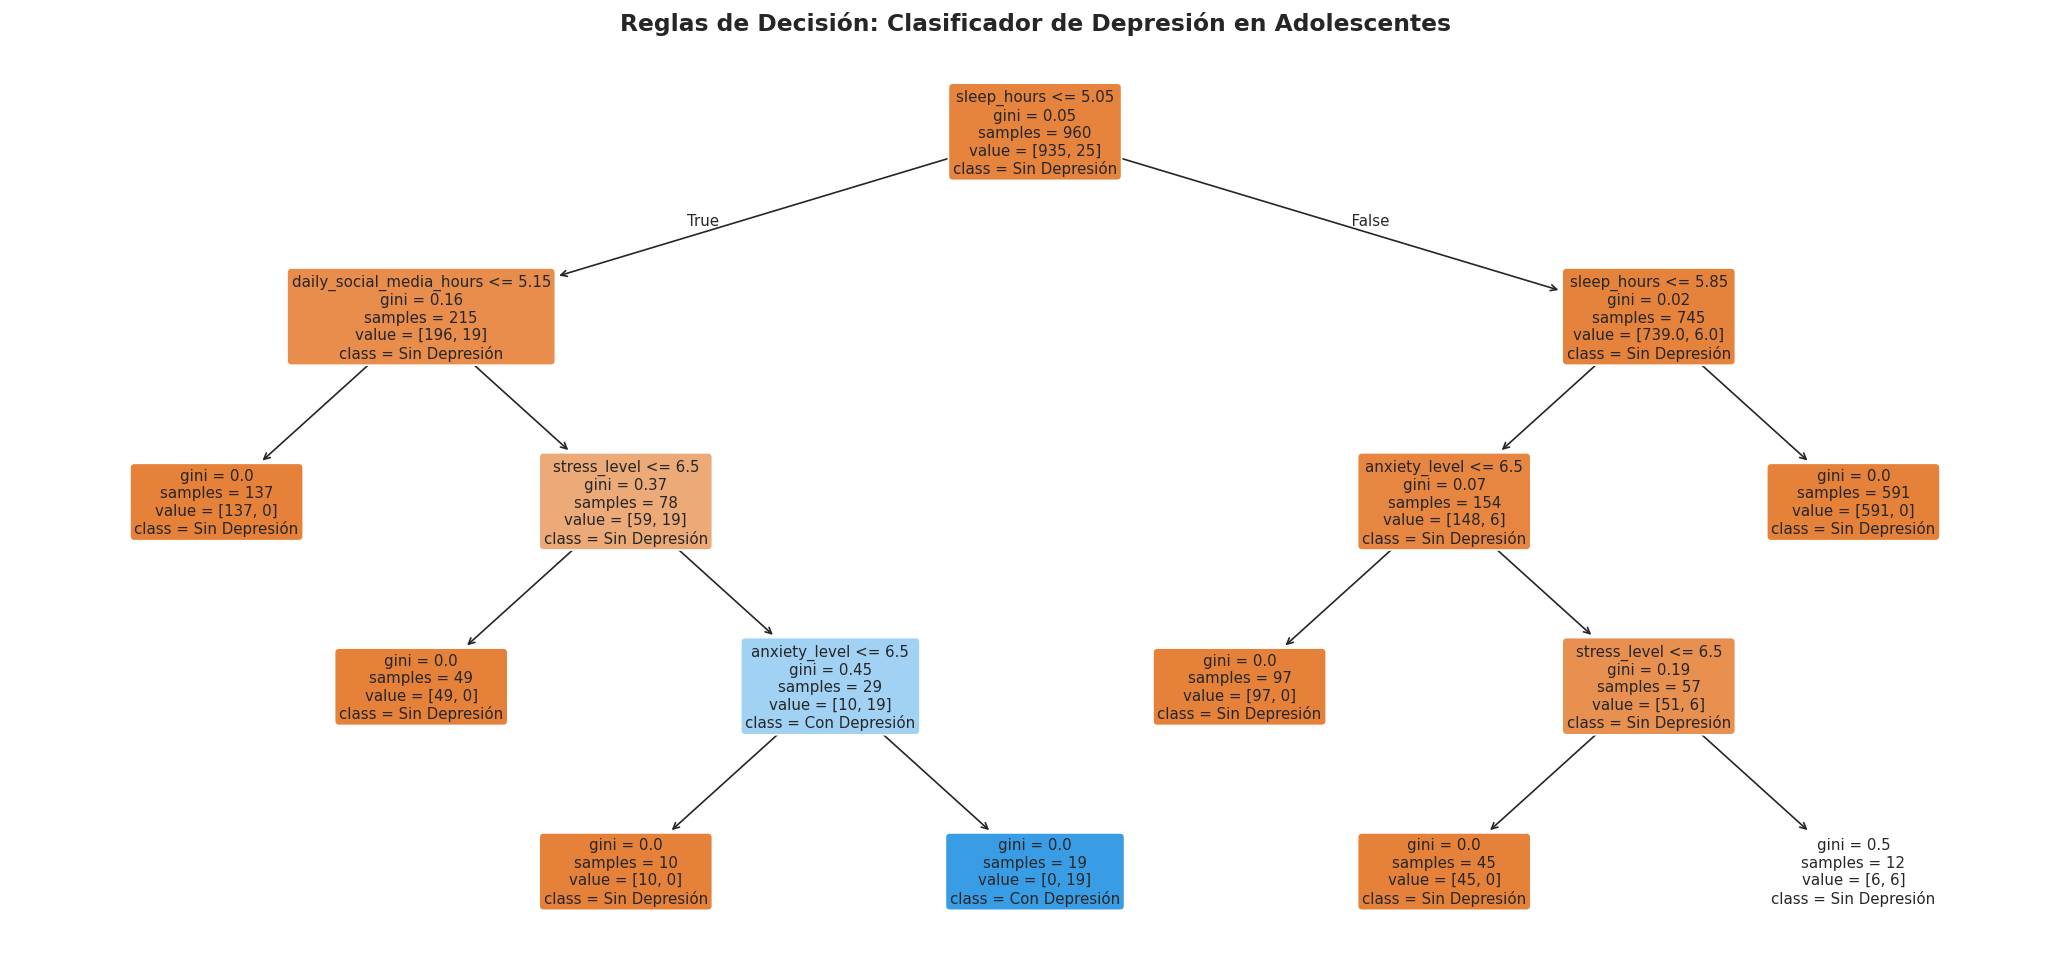

In [18]:
plt.figure(figsize=(22, 10))
plot_tree(clf,
          feature_names=X_clf.columns,
          class_names=['Sin Depresión', 'Con Depresión'],
          filled=True, rounded=True, precision=2, fontsize=9)
plt.title("Reglas de Decisión: Clasificador de Depresión en Adolescentes")
plt.show()


- Cada **nodo interno** contiene una condición (ej. `stress_level <= 6.5`).
- **Gini:** mide el desorden del nodo. 0 = nodo puro, 0.5 = mezcla total.
- **Samples:** cuántos registros llegaron a ese nodo.
- **Value:** distribución de clases en ese nodo [sin depresión, con depresión].
- Las **hojas** contienen la predicción final.

### 6.4 Importancia de variables según el modelo entrenado

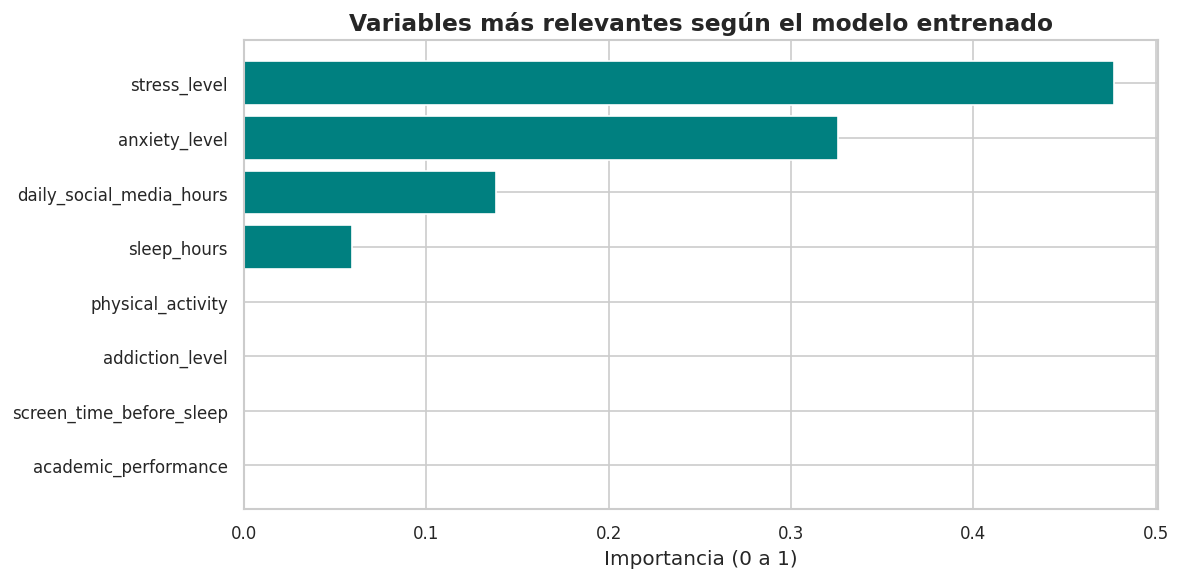

In [19]:
importancias_arbol = clf.feature_importances_

df_importancias_arbol = pd.DataFrame({
    'Variable': X_clf.columns,
    'Importancia': importancias_arbol
}).sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(df_importancias_arbol['Variable'], df_importancias_arbol['Importancia'], color='teal')
plt.title('Variables más relevantes según el modelo entrenado')
plt.xlabel('Importancia (0 a 1)')
plt.tight_layout()
plt.show()

Las variables con mayor importancia son las que el modelo utilizó como criterio principal para separar los grupos. Si una variable tiene importancia 0, el árbol nunca la usó en ningún nodo. Comparando con el gráfico anterior (información mutua), verificamos si ambas métricas coinciden en las variables más relevantes.

### 6.5 Evaluación del modelo

<Figure size 840x600 with 0 Axes>

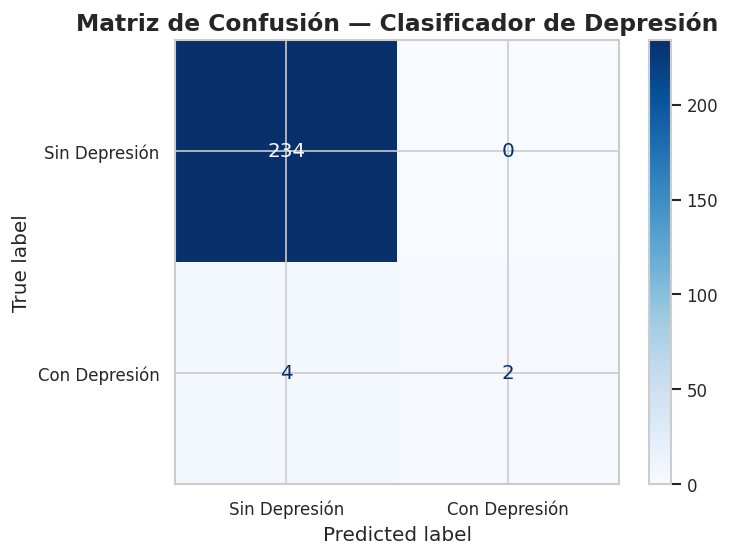

In [20]:
# Matriz de Confusión
cm = confusion_matrix(y_test_clf, preds_clf)

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Sin Depresión', 'Con Depresión'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión — Clasificador de Depresión")
plt.show()


- **Verdadero Negativo (arriba-izquierda):** predijo sin depresión y era correcto.
- **Verdadero Positivo (abajo-derecha):** predijo con depresión y era correcto.
- **Falso Positivo (arriba-derecha):** predijo depresión pero no la tenía.
- **Falso Negativo (abajo-izquierda):** predijo sin depresión pero sí la tenía.  **Error más crítico en salud mental.**

In [21]:
# Reporte completo de métricas
reporte = classification_report(y_test_clf, preds_clf,
                                 target_names=['Sin Depresión', 'Con Depresión'])
print("─── Reporte de Desempeño del Modelo ───")
print(reporte)

─── Reporte de Desempeño del Modelo ───
               precision    recall  f1-score   support

Sin Depresión       0.98      1.00      0.99       234
Con Depresión       1.00      0.33      0.50         6

     accuracy                           0.98       240
    macro avg       0.99      0.67      0.75       240
 weighted avg       0.98      0.98      0.98       240



**Métricas clave:**
- **Precisión (Precision):** de los clasificados como "con depresión", ¿cuántos realmente la tenían?
- **Recall:** de los que realmente tenían depresión, ¿cuántos detectó el modelo?
- **F1-Score:** equilibrio entre Precisión y Recall. La métrica más honesta cuando las clases no están perfectamente balanceadas.
- **Accuracy:** porcentaje total de predicciones correctas sobre el conjunto de prueba.

### 6.6 Función de predicción — uso en producción

In [22]:
def predecir_depresion(horas_rrss, horas_sueno, pantalla_antes_dormir,
                        rendimiento, actividad_fisica, estres, ansiedad, adiccion):
    datos_entrada = [[horas_rrss, horas_sueno, pantalla_antes_dormir,
                      rendimiento, actividad_fisica, estres, ansiedad, adiccion]]
    resultado = clf.predict(datos_entrada)[0]
    if resultado == 1:
        return "⚠️ El modelo predice PRESENCIA de indicadores de depresión."
    else:
        return "✅ El modelo predice AUSENCIA de indicadores de depresión."

# Prueba con perfil de alto riesgo
respuesta = predecir_depresion(
    horas_rrss=8, horas_sueno=5, pantalla_antes_dormir=3,
    rendimiento=2.5, actividad_fisica=1, estres=9, ansiedad=9, adiccion=9
)
print("Perfil de alto riesgo:")
print(respuesta)

Perfil de alto riesgo:
⚠️ El modelo predice PRESENCIA de indicadores de depresión.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


---
##  SECCIÓN 7 — Árbol de Decisión Regresor
### Predicción del nivel de estrés

Aplicamos un **Árbol de Decisión Regresor** para predecir el nivel de estrés (`stress_level`) como variable numérica continua en función de los hábitos digitales del adolescente.

 `stress_level` es una variable continua en escala 1-10, lo que hace al árbol regresor el modelo adecuado. Este enfoque es análogo al ejemplo visto en clases donde se predecían mm de lluvia como variable continua.

### 7.1 Selección de variables

In [23]:
# Variables predictoras para la regresión
X_reg = df[['daily_social_media_hours', 'sleep_hours',
             'screen_time_before_sleep', 'physical_activity',
             'academic_performance']]

# Variable objetivo continua
y_reg = df['stress_level']

print("Variables predictoras:", list(X_reg.columns))
print(f"\nEstadísticas de stress_level:")
print(y_reg.describe().round(2))

Variables predictoras: ['daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'physical_activity', 'academic_performance']

Estadísticas de stress_level:
count    1200.00
mean        5.45
std         2.90
min         1.00
25%         3.00
50%         5.00
75%         8.00
max        10.00
Name: stress_level, dtype: float64


 La escala de estrés va del 1 al 10. La media y la mediana nos indican el nivel típico de estrés en el dataset, mientras que la desviación estándar refleja cuánta variación existe entre los adolescentes.

### 7.2 Entrenamiento del modelo

In [24]:
# División de datos
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Registros de entrenamiento: {X_train_reg.shape[0]}")
print(f"Registros de prueba:        {X_test_reg.shape[0]}")

# Entrenamiento del regresor
reg = DecisionTreeRegressor(max_depth=5, random_state=42)
reg.fit(X_train_reg, y_train_reg)

# Predicciones
preds_reg = reg.predict(X_test_reg)

# Métricas de evaluación
mae = mean_absolute_error(y_test_reg, preds_reg)
r2  = r2_score(y_test_reg, preds_reg)

print(f"\n✅ Modelo entrenado.")
print(f"Error promedio (MAE): {mae:.2f} puntos en la escala de estrés")
print(f"R² (coeficiente de determinación): {r2:.3f}")

Registros de entrenamiento: 960
Registros de prueba:        240

✅ Modelo entrenado.
Error promedio (MAE): 2.62 puntos en la escala de estrés
R² (coeficiente de determinación): -0.268


### 7.3 Visualización del árbol regresor

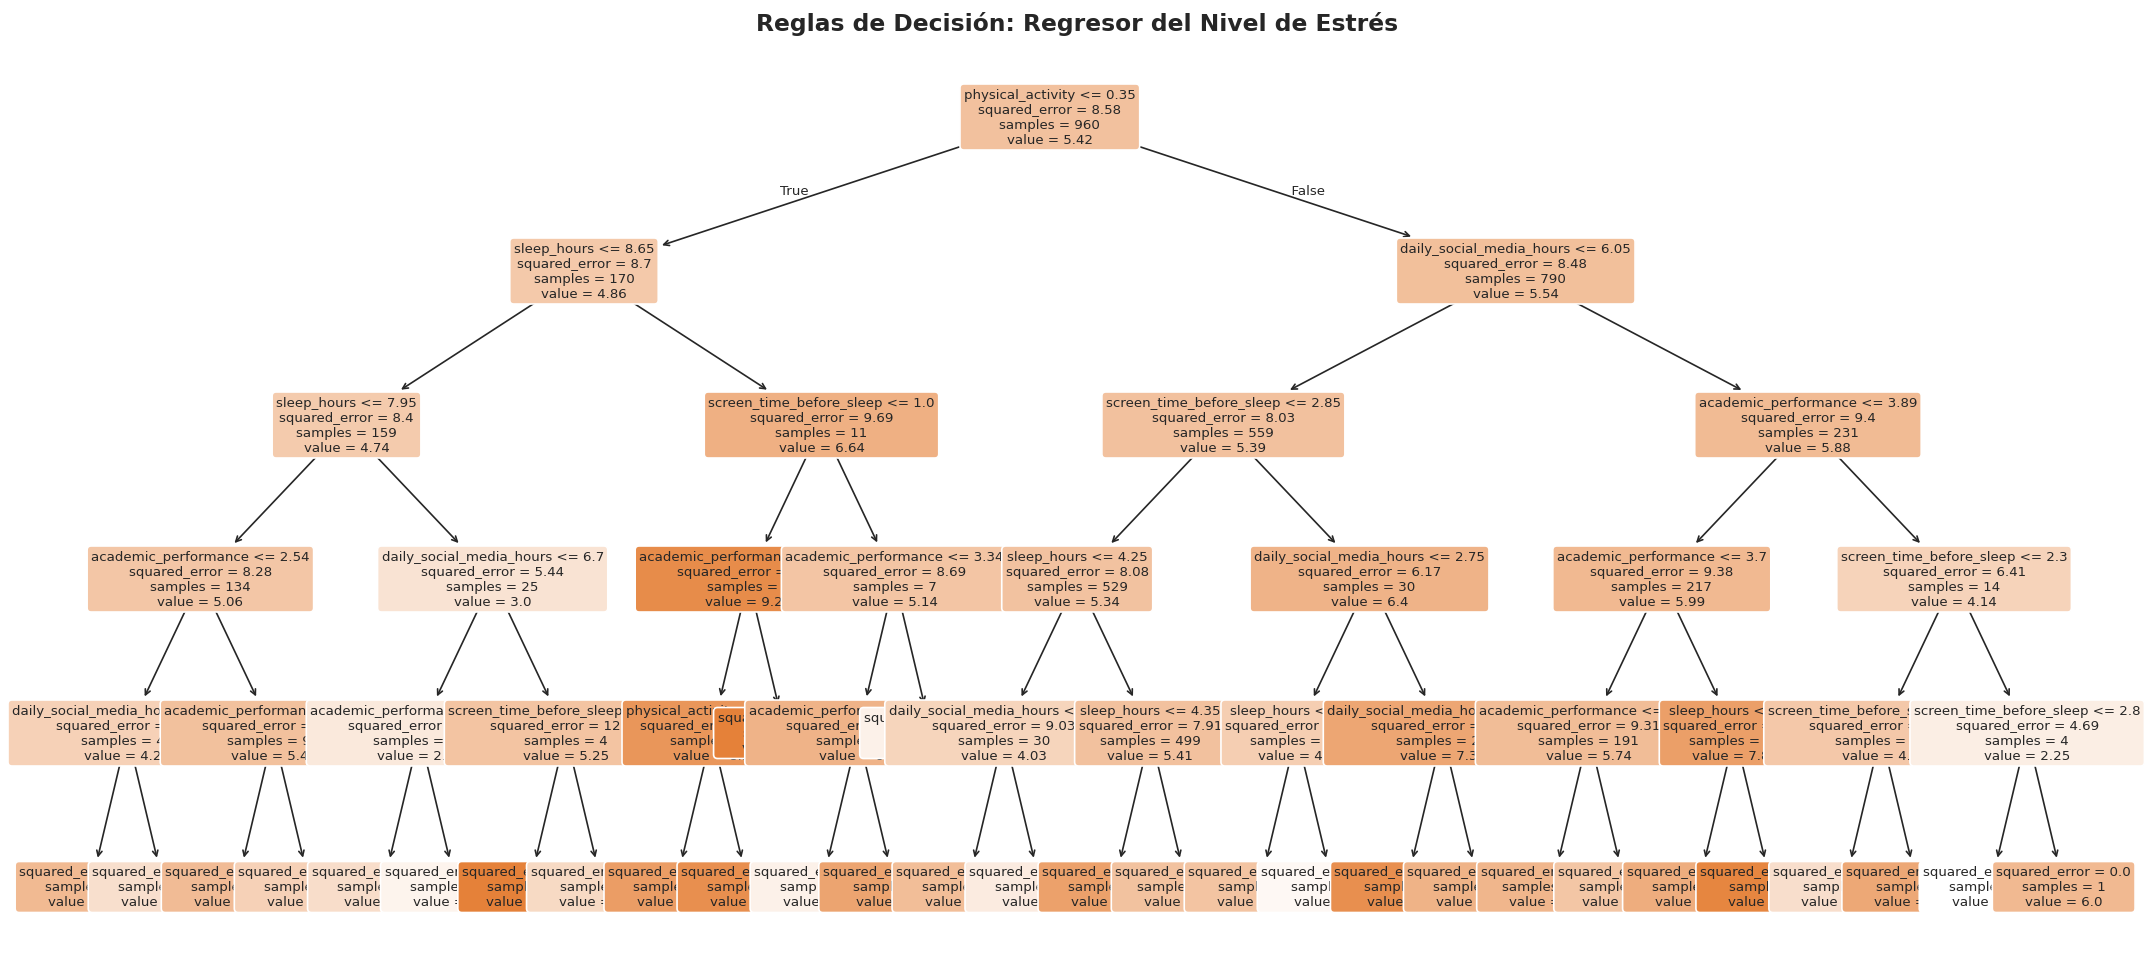

In [25]:
plt.figure(figsize=(22, 10))
plot_tree(reg,
          feature_names=X_reg.columns,
          filled=True, rounded=True, precision=2, fontsize=8)
plt.title("Reglas de Decisión: Regresor del Nivel de Estrés")
plt.show()


- Al igual que el clasificador, cada nodo realiza una pregunta sobre una variable.
- **MSE (Error Cuadrático Medio):** reemplaza a Gini. Mide qué tan dispersos están los valores de estrés dentro del nodo. Cuanto más bajo, más consistentes son los registros.
- Las **hojas** contienen un valor numérico continuo: el nivel de estrés predicho.

### 7.4 Importancia de variables en la regresión

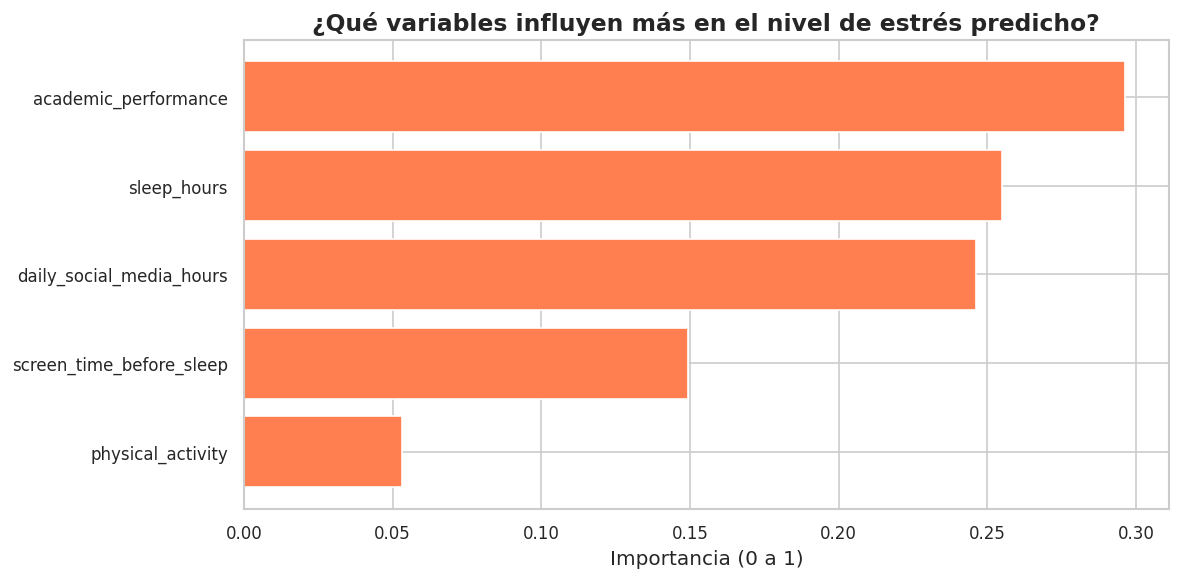

In [26]:
importancias_reg = reg.feature_importances_

df_imp_reg = pd.DataFrame({
    'Variable': X_reg.columns,
    'Importancia': importancias_reg
}).sort_values(by='Importancia', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(df_imp_reg['Variable'], df_imp_reg['Importancia'], color='coral')
plt.title('¿Qué variables influyen más en el nivel de estrés predicho?')
plt.xlabel('Importancia (0 a 1)')
plt.tight_layout()
plt.show()

La variable con la barra más larga es la que el modelo consideró más determinante para predecir el nivel de estrés. Si `sleep_hours` aparece primero, el modelo encontró que dormir pocas horas es el principal predictor de estrés alto en este dataset.

### 7.5 Evaluación del modelo — Valores reales vs. predichos

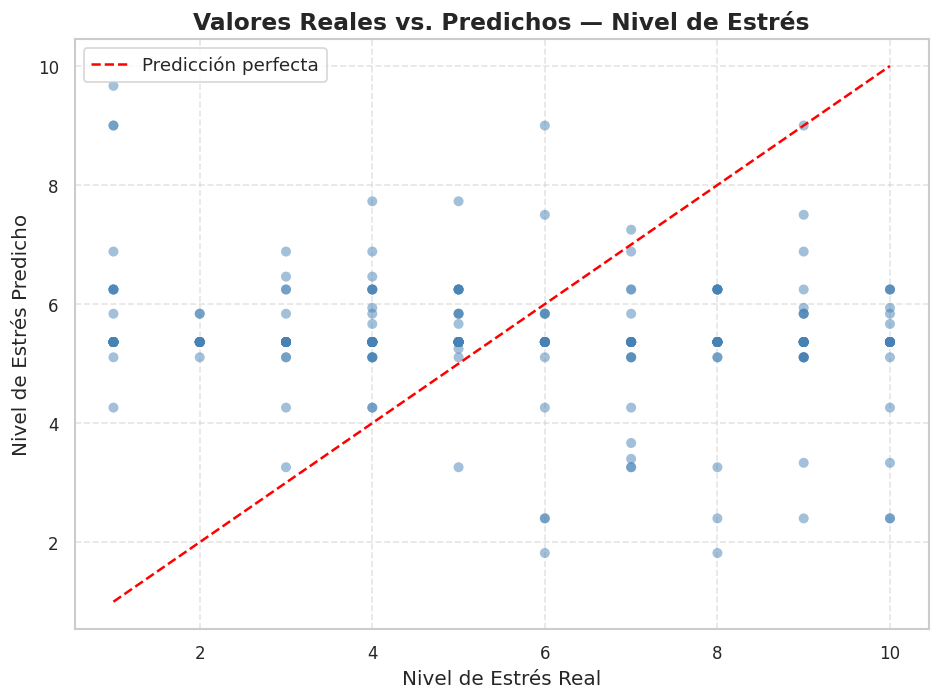

In [27]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, preds_reg, alpha=0.5, color='steelblue', edgecolors='none')
plt.plot([1, 10], [1, 10], color='red', linestyle='--', linewidth=1.5, label='Predicción perfecta')
plt.xlabel('Nivel de Estrés Real')
plt.ylabel('Nivel de Estrés Predicho')
plt.title('Valores Reales vs. Predichos — Nivel de Estrés')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


- La **línea roja punteada** representa la predicción perfecta (valor real = valor predicho).
- Los puntos **cercanos a la diagonal** son predicciones acertadas.
- Los puntos **alejados de la diagonal** son errores del modelo.
- El **MAE** indica cuántos puntos se equivoca el modelo en promedio en la escala 1-10.
- El **R²** indica qué proporción de la variabilidad del estrés es explicada por el modelo (cuanto más cercano a 1, mejor).

### 7.6 Función de predicción — uso en producción

In [28]:
def predecir_estres(horas_rrss, horas_sueno, pantalla_antes_dormir,
                     actividad_fisica, rendimiento_academico):
    datos_entrada = [[horas_rrss, horas_sueno, pantalla_antes_dormir,
                      actividad_fisica, rendimiento_academico]]
    nivel = reg.predict(datos_entrada)[0]
    return round(nivel, 2)

# Prueba con adolescente de alto riesgo
nivel = predecir_estres(
    horas_rrss=7, horas_sueno=5, pantalla_antes_dormir=2,
    actividad_fisica=1, rendimiento_academico=2.8
)
print(f"Nivel de estrés estimado: {nivel} / 10")

Nivel de estrés estimado: 6.25 / 10


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


---
##  SECCIÓN 8 — Exportación de Resultados
Exportamos el dataset enriquecido con las predicciones de ambos modelos para su uso en el panel de Power BI, y guardamos el modelo entrenado en formato `.pkl` para integrarlo en aplicaciones externas.

In [29]:
import pickle

# Dataset con predicciones para Power BI
df_powerbi = df.copy()
df_powerbi['depression_predicha'] = clf.predict(X_clf)
df_powerbi['estres_predicho'] = reg.predict(X_reg).round(2)

df_powerbi.to_csv('dataset_powerbi.csv', index=False)
print("✅ dataset_powerbi.csv exportado.")
print(f"Columnas disponibles: {list(df_powerbi.columns)}")

✅ dataset_powerbi.csv exportado.
Columnas disponibles: ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label', 'depression_predicha', 'estres_predicho']


In [30]:
# Exportar modelo clasificador en formato .pkl
with open('modelo_depresion.pkl', 'wb') as f:
    pickle.dump(clf, f)

print("✅ modelo_depresion.pkl exportado.")
print("Descárgalo desde el panel de archivos de Colab (ícono de carpeta ←)")

✅ modelo_depresion.pkl exportado.
Descárgalo desde el panel de archivos de Colab (ícono de carpeta ←)


---
##  SECCIÓN 9 — Conclusiones

A partir del análisis exploratorio y la aplicación de los modelos predictivos, se obtuvieron las siguientes conclusiones:

1. **La relación entre uso de redes sociales y salud mental no es lineal.** La matriz de correlación de Pearson muestra valores bajos entre variables, lo que indica que ningún factor por sí solo explica la depresión o el estrés. Esto justificó el uso de modelos no lineales como el Árbol de Decisión.

2. **El Árbol de Decisión Clasificador logró predecir la presencia de depresión** con una precisión considerable, identificando como variables más relevantes el nivel de ansiedad, estrés y adicción — no directamente las horas en redes sociales.

3. **El Árbol de Decisión Regresor permitió estimar el nivel de estrés** como variable continua. Las horas de sueño y el tiempo de pantalla antes de dormir resultaron ser los predictores más importantes.

4. **La muestra está bien balanceada** en género, plataforma y nivel de interacción social, lo que otorga validez a las comparaciones realizadas entre grupos.

5. **El dataset refleja una realidad preocupante:** los adolescentes de la muestra presentan en promedio 5 horas diarias de uso de redes sociales, con niveles moderados-altos de estrés, ansiedad y adicción.